Preprocessing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import scipy
import re

df = pd.read_csv("atp_tennis.csv")

Conclusion 1: Hypothesis Testing with Chi-squared
<br>  Question: Does the court surface affect upset rate?
<br>Null Hypothesis (H0): The court surface does not affect the upset rate.
<br> Alternative Hypothesis: The court surface does affect the upset rate.

Chi-squared statistic: 15.909028744128591
p-value: 0.0011837362128475967
Degrees of freedom: 3


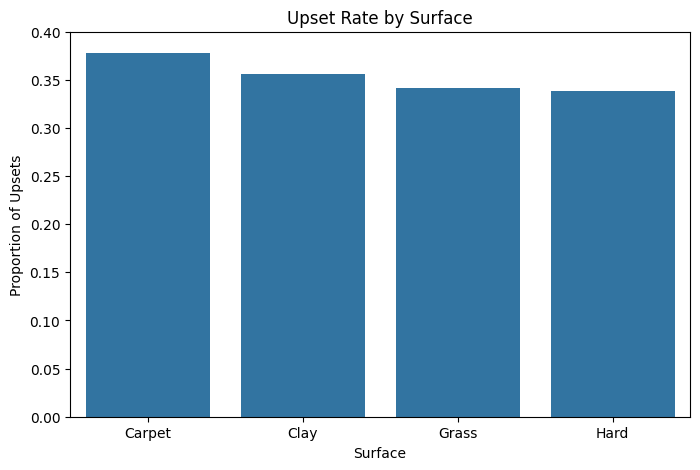

In [3]:
# Keep only rows with known Rankings
valid = df[(df['Rank_1'] > 0) & (df['Rank_2'] > 0)].copy()

# Create a column for if Player_1 won or not and for if Player_1 was higher ranked
valid["p1_wins"] = (valid['Winner'] == valid['Player_1'])
valid['p1_favored'] = (valid['Rank_1'] < valid['Rank_2'])

# An upset in this case is defined as a game where the lower ranked player won
valid['upset'] = (valid['p1_favored'] != valid['p1_wins']).astype(int)

contingency = pd.crosstab(valid["Surface"], valid["upset"])

chi2, p, dof, expected = scipy.stats.chi2_contingency(contingency)

print("Chi-squared statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

import seaborn as sns

# Graph upset rate by surface
upset_rate = valid.groupby("Surface")["upset"].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=upset_rate, x="Surface", y="upset")

plt.title("Upset Rate by Surface")
plt.ylabel("Proportion of Upsets")
plt.xlabel("Surface")
plt.ylim(0, 0.4)

plt.show()

Conclusion: Since p-value < 0.05, we reject the null hypothesis and conclude that court surface does have an affect on upset rate.

Conclusion 2: Hypothesis Testing with T-test
<br>  Question: Does court type (indoor/outdoor) affect the average total games played per match in best-of-3 matches?
<br>Null Hypothesis (H0): The court type does not affect the average total games played per match in best-of-3 matches.
<br> Alternative Hypothesis: The court type does affect the average total games played per match in best-of-3 matches.


t-statistic: 8.312744262583061
p-value: 1.0747932845028804e-16
Reject H0: match length differs by court type
         count       mean       std
Court                              
Indoor    5618  23.451228  6.025717
Outdoor  20001  22.700465  5.820329


<Figure size 640x480 with 0 Axes>

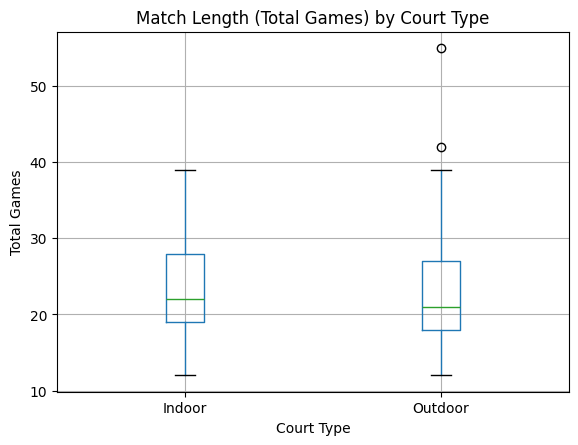

In [4]:
# keep only relevant columns
ct = df[["Court", "Score", "Best of"]]
ct = ct[ct["Best of"] == 3]

# drop missing values
ct = ct.dropna()

# function to compute match length
def compute_total_games(score_string):

    # if score is not a string, reject it
    if not isinstance(score_string, str):
        return None

    # remove leading/trailing spaces
    score_string = score_string.strip()

    total_games = 0

    # split into sets
    sets = score_string.split()

    for set_score in sets:

        # remove tiebreak info, like 7-6(5) -> 7-6
        set_score = re.sub(r"\(.*?\)", "", set_score)

        # only process things that look like x-y
        if "-" not in set_score:
            continue

        parts = set_score.split("-")

        # should have exactly 2 numbers
        if len(parts) != 2:
            continue

        try:
            games1 = int(parts[0])
            games2 = int(parts[1])
            total_games += games1 + games2
        except ValueError:
            return None

    # if nothing valid was counted, reject row
    if total_games == 0:
        return None

    return total_games

ct["total_games"] = ct["Score"].apply(compute_total_games)

ct = ct[ct["Court"].isin(["Indoor", "Outdoor"])]

indoor = ct[ct["Court"] == "Indoor"]["total_games"]
outdoor = ct[ct["Court"] == "Outdoor"]["total_games"]

stat, p_value = ttest_ind(indoor, outdoor, equal_var=False)  # t-test

print("t-statistic:", stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: match length differs by court type")
else:
    print("Fail to reject H0: no significant difference")

print(ct.groupby("Court")["total_games"].agg(["count", "mean", "std"]))

plt.figure()
ct.boxplot(column="total_games", by="Court")
plt.title("Match Length (Total Games) by Court Type")
plt.suptitle("")
plt.xlabel("Court Type")
plt.ylabel("Total Games")
plt.show()


Conclusion: Since p-value < 0.05, we reject the null hypothesis and conclude that court type does affect the average total games played per match in best-of-3 matches.

Conclusion 3: Outlier Detection

Question: Are there outliers in the rankings of people who defeat top-10 players? In other words, what are the biggest upsets?

Statistically extreme outliers (Rank > 126): 75


,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,...,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score,p1_wins,p1_favored,upset,Winner_Rank
491,Mexican Open,2000-02-21,International Gold,Outdoor,Clay,2nd Round,3,Kuerten G.,Chela J.I.,Chela J.I.,...,129.0,-1.0,-1.0,-1.00,-1.00,6-3 6-7 4-6,False,True,1,129.0
578,Chevrolet Cup,2000-02-28,International,Outdoor,Clay,1st Round,3,Ulihrach B.,Rios M.,Ulihrach B.,...,7.0,-1.0,-1.0,-1.00,-1.00,6-4 7-6,True,False,1,151.0
1410,Gerry Weber Open,2000-06-12,International,Outdoor,Grass,Quarterfinals,3,Prinosil D.,Lapentti N.,Prinosil D.,...,9.0,-1.0,-1.0,-1.00,-1.00,6-3 7-6,True,False,1,130.0
1412,Gerry Weber Open,2000-06-12,International,Outdoor,Grass,Semifinals,3,Prinosil D.,Kafelnikov Y.,Prinosil D.,...,5.0,-1.0,-1.0,-1.00,-1.00,6-4 7-6,True,False,1,130.0
1477,Nottingham Open,2000-06-19,International,Outdoor,Grass,1st Round,3,Pioline C.,Parmar A.,Parmar A.,...,151.0,-1.0,-1.0,-1.00,-1.00,5-7 6-7,False,True,1,151.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27168,China Open,2009-10-06,ATP500,Outdoor,Hard,1st Round,3,Kubot L.,Roddick A.,Kubot L.,...,6.0,418.0,4920.0,12.00,1.02,6-2 6-4,True,False,1,143.0
27193,Rakuten Japan Open Tennis Championships,2009-10-06,ATP500,Outdoor,Hard,1st Round,3,Del Potro J.M.,Roger-Vasselin E.,Roger-Vasselin E.,...,189.0,6555.0,283.0,1.03,11.00,4-6 4-6,False,True,1,189.0
30334,Australian Open,2011-01-22,Grand Slam,Outdoor,Hard,3rd Round,5,Raonic M.,Youzhny M.,Raonic M.,...,10.0,351.0,2920.0,3.50,1.28,6-4 7-5 4-6 6-4,True,False,1,152.0
30583,Open 13,2011-02-18,ATP250,Indoor,Hard,Quarterfinals,3,Melzer J.,Tursunov D.,Tursunov D.,...,129.0,2865.0,428.0,1.53,2.37,4-6 6-2 1-6,False,True,1,129.0


,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,...,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score,p1_wins,p1_favored,upset,Winner_Rank
4645,Dutch Open,2001-07-16,International,Outdoor,Clay,1st Round,3,Grosjean S.,Chela J.I.,Chela J.I.,...,826.0,-1.0,-1.0,1.31575,2.8875,4-6 4-6,False,True,1,826.0


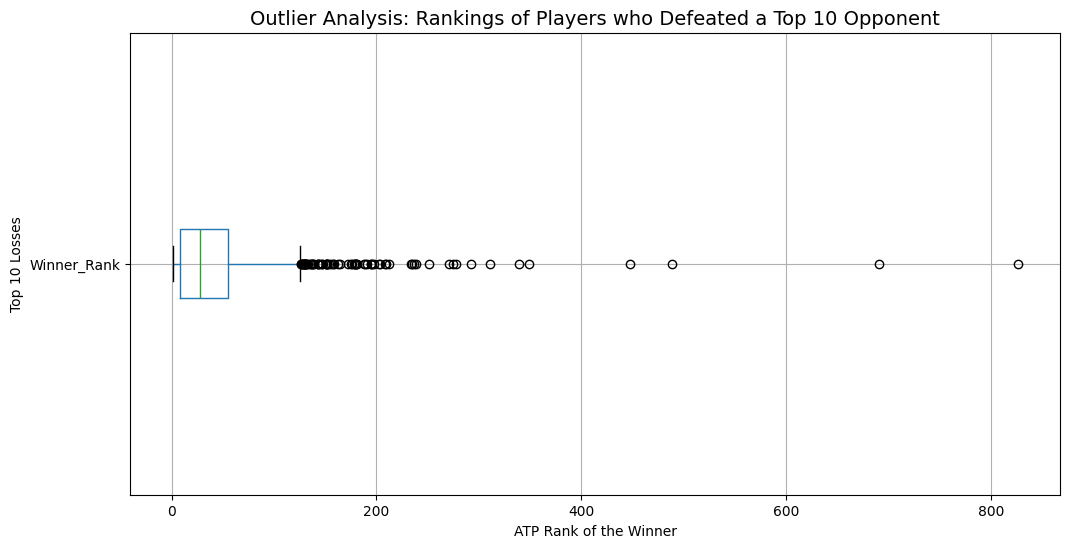

In [5]:
#filter to matches where top 10 players played and lost
top_10_losses=valid[((valid['Rank_1']<=10)&(valid['Winner']==valid['Player_2']))|((valid['Rank_2']<= 10)&(valid['Winner']==valid['Player_1']))].copy()

#compile list of rankings of the winners in such matches
top_10_losses['Winner_Rank'] = top_10_losses.apply(lambda x: x['Rank_1'] if x['Winner'] == x['Player_1'] else x['Rank_2'],axis=1)

#create quartile range
Q1=top_10_losses['Winner_Rank'].quantile(0.25)
Q3=top_10_losses['Winner_Rank'].quantile(0.75)
IQR=Q3-Q1
outlier_threshold=Q3+1.5*IQR

#identify outliers
outliers = top_10_losses[top_10_losses['Winner_Rank']>outlier_threshold]
print(f"Statistically extreme outliers (Rank > {outlier_threshold:.0f}): {len(outliers)}")
display(outliers)

#indentifying the biggest outlier/upset
biggest_outlier = outliers.loc[outliers['Winner_Rank'].idxmax()]
display(biggest_outlier.to_frame().T)

#Create box plot
plt.figure(figsize=(12, 6))
top_10_losses.boxplot(column='Winner_Rank',vert=False)
plt.title("Outlier Analysis: Rankings of Players who Defeated a Top 10 Opponent", fontsize=14)
plt.xlabel("ATP Rank of the Winner")
plt.ylabel("Top 10 Losses")
plt.show()


Conclusion: There are 177 outliers in the rankings of people who defeated top 10 players, as listed above. The biggest outlier/upset was 826 ranked Chela defeating 7 ranked Grosjean.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import ttest_ind
import scipy
import re

# Load the dataset
df = pd.read_csv("atp_tennis.csv")

print(f"Dataset shape: {df.shape}")
print(df.dtypes)
df.head()

Dataset shape: (31183, 17)
Tournament     object
Date           object
Series         object
Court          object
Surface        object
Round          object
Best of         int64
Player_1       object
Player_2       object
Winner         object
Rank_1        float64
Rank_2        float64
Pts_1         float64
Pts_2         float64
Odd_1         float64
Odd_2         float64
Score          object
dtype: object


,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63.0,77.0,-1.0,-1.0,-1.0,-1.0,6-4 6-2
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56.0,5.0,-1.0,-1.0,-1.0,-1.0,3-6 3-6
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Escude N.,Baccanello P.,Escude N.,40.0,655.0,-1.0,-1.0,-1.0,-1.0,6-7 7-5 6-3
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Knippschild J.,Federer R.,Federer R.,87.0,65.0,-1.0,-1.0,-1.0,-1.0,1-6 4-6
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Fromberg R.,Woodbridge T.,Fromberg R.,81.0,198.0,-1.0,-1.0,-1.0,-1.0,7-6 5-7 6-4


In [7]:
# Keep only rows where both players have valid (positive) rankings
valid = df[(df['Rank_1'] > 0) & (df['Rank_2'] > 0)].copy()
print(f"Rows with valid rankings: {len(valid)} / {len(df)} ({len(valid)/len(df)*100:.1f}%)")

# Determine which player was favored (lower rank = better)
valid['p1_wins']    = (valid['Winner'] == valid['Player_1'])
valid['p1_favored'] = (valid['Rank_1'] < valid['Rank_2'])

# An upset is when the lower-ranked (higher number) player wins
valid['upset'] = (valid['p1_favored'] != valid['p1_wins']).astype(int)

print(f"\nOverall upset rate: {valid['upset'].mean():.3f}  ({valid['upset'].sum():,} upsets out of {len(valid):,} matches)")
print(f"\nClass balance (0 = expected result, 1 = upset):")
print(valid['upset'].value_counts())

Rows with valid rankings: 31156 / 31183 (99.9%)

Overall upset rate: 0.347  (10,796 upsets out of 31,156 matches)

Class balance (0 = expected result, 1 = upset):
upset
0    20360
1    10796
Name: count, dtype: int64


In [8]:
# Keep only rows where both players have valid (positive) rankings
valid = df[(df['Rank_1'] > 0) & (df['Rank_2'] > 0)].copy()
print(f"Rows with valid rankings: {len(valid)} / {len(df)} ({len(valid)/len(df)*100:.1f}%)")

# Determine which player was favored (lower rank = better)
valid['p1_wins']    = (valid['Winner'] == valid['Player_1'])
valid['p1_favored'] = (valid['Rank_1'] < valid['Rank_2'])

# An upset is when the lower-ranked (higher number) player wins
valid['upset'] = (valid['p1_favored'] != valid['p1_wins']).astype(int)

print(f"\nOverall upset rate: {valid['upset'].mean():.3f}  ({valid['upset'].sum():,} upsets out of {len(valid):,} matches)")
print(f"\nClass balance (0 = expected result, 1 = upset):")
print(valid['upset'].value_counts())

Rows with valid rankings: 31156 / 31183 (99.9%)

Overall upset rate: 0.347  (10,796 upsets out of 31,156 matches)

Class balance (0 = expected result, 1 = upset):
upset
0    20360
1    10796
Name: count, dtype: int64


In [9]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

# ====== assumes df and valid are already created as in your earlier cells ======
# valid must already have: p1_favored, upset, Odd_1, Odd_2, Rank_1, Rank_2, Round, Series, Surface, Best of

# keep only rows with valid betting odds
odds_valid = valid[(valid["Odd_1"] > 0) & (valid["Odd_2"] > 0)].copy()

# rank-based features
odds_valid["rank_diff"] = (odds_valid["Rank_1"] - odds_valid["Rank_2"]).abs()
odds_valid["log_rank_diff"] = np.log1p(odds_valid["rank_diff"])
odds_valid["favored_rank"] = odds_valid[["Rank_1", "Rank_2"]].min(axis=1)
odds_valid["log_favored_rank"] = np.log1p(odds_valid["favored_rank"])

# implied probability of the favorite from odds (normalized for overround)
raw_fav = odds_valid.apply(lambda r: 1/r["Odd_1"] if r["p1_favored"] else 1/r["Odd_2"], axis=1)
raw_dog = odds_valid.apply(lambda r: 1/r["Odd_2"] if r["p1_favored"] else 1/r["Odd_1"], axis=1)
overround = raw_fav + raw_dog
odds_valid["implied_prob_fav"] = raw_fav / overround

# round + series encodings
round_order = {
    "1st Round": 1, "2nd Round": 2, "3rd Round": 3, "4th Round": 4,
    "Round Robin": 3, "Quarterfinals": 5, "Semifinals": 6, "The Final": 7, "Final": 7
}
odds_valid["round_num"] = odds_valid["Round"].map(round_order).fillna(3).astype(int)

series_order = {
    "International": 1, "International Gold": 2, "ATP250": 2,
    "ATP500": 3, "Masters": 4, "Masters 1000": 4,
    "Masters Cup": 5, "Grand Slam": 5
}
odds_valid["series_tier"] = odds_valid["Series"].map(series_order).fillna(2).astype(int)

# build X, y
feature_cols = ["log_rank_diff", "log_favored_rank", "implied_prob_fav",
                "round_num", "series_tier", "Best of", "Surface"]
X = pd.get_dummies(odds_valid[feature_cols], columns=["Surface"])
y = odds_valid["upset"].astype(int)

print("Matches used:", len(odds_valid))
print("Upset rate:", round(y.mean(), 4))
print("X shape:", X.shape)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain upset rate:", round(y_train.mean(), 4), "Test upset rate:", round(y_test.mean(), 4))

# baseline
y_pred_base = np.zeros(len(y_test), dtype=int)
print("\nBaseline (always predict no upset)")
print("Accuracy:", round(accuracy_score(y_test, y_pred_base), 4))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred_base), 4))
print("F1:", round(f1_score(y_test, y_pred_base, zero_division=0), 4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_base))

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

def eval_model(name, model):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    # map metrics to their values for later use
    results[name] = {
        "ROC-AUC": round(roc_auc_score(y_test, proba), 4),
        "PR-AUC": round(average_precision_score(y_test, proba), 4),
        "F1": round(f1_score(y_test, pred, zero_division=0), 4),
        "Balanced Acc": round(balanced_accuracy_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, pred, zero_division=0), 4),
        "Accuracy": round(accuracy_score(y_test, pred), 4),
    }

    print(f"\n{name}")
    for m, v in results[name].items():
        print(f"{m}: {v}")

for name, model in models.items():
    eval_model(name, model)

Matches used: 27414
Upset rate: 0.3451
X shape: (27414, 10)

Train upset rate: 0.3451 Test upset rate: 0.3451

Baseline (always predict no upset)
Accuracy: 0.6549
Balanced accuracy: 0.5
F1: 0.0
Confusion matrix:
 [[3591    0]
 [1892    0]]

Logistic Regression
ROC-AUC: 0.7195
PR-AUC: 0.5647
F1: 0.5679
Balanced Acc: 0.6576
Precision: 0.5077
Recall: 0.6443
Accuracy: 0.6617

Random Forest
ROC-AUC: 0.7055
PR-AUC: 0.5474
F1: 0.5377
Balanced Acc: 0.6439
Precision: 0.5238
Recall: 0.5523
Accuracy: 0.6723

Gradient Boosting
ROC-AUC: 0.7192
PR-AUC: 0.5644
F1: 0.4169
Balanced Acc: 0.6079
Precision: 0.6329
Recall: 0.3108
Accuracy: 0.7


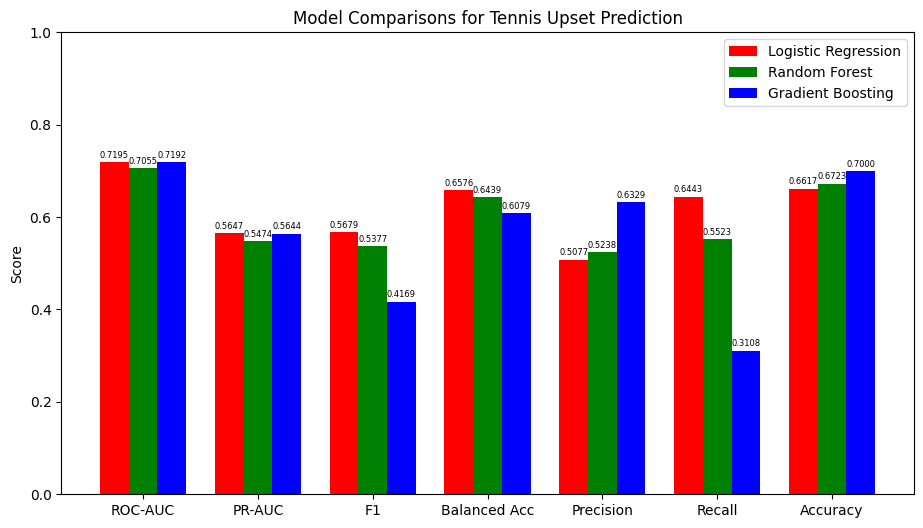

In [10]:
# axes names
results_df = pd.DataFrame(results).T
metrics = results_df.columns.tolist()
model_names = results_df.index.tolist()

#set up plot metadata
x = np.arange(len(metrics))
colors = ["red", "green", "blue"]
width = 0.25
fig, ax = plt.subplots(figsize=(11, 6))

# create sick grouped bar chart
for i, name in enumerate(model_names):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, results_df.loc[name], width, label=name, color=colors[i])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title("Model Comparisons for Tennis Upset Prediction")
ax.legend(loc="upper right")
plt.show()

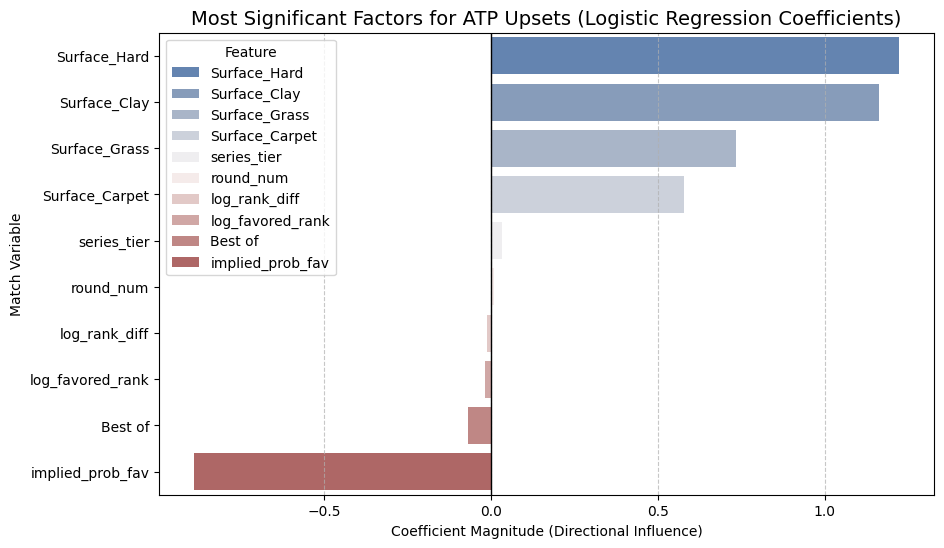

In [11]:
lr_model = models["Logistic Regression"].named_steps['clf']
feature_names = X.columns

importance = lr_model.coef_[0]

feat_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importance, hue='Feature', palette="vlag", legend=True)
plt.axvline(x=0, color='black', lw=1)
plt.title('Most Significant Factors for ATP Upsets (Logistic Regression Coefficients)', fontsize=14)
plt.xlabel('Coefficient Magnitude (Directional Influence)')
plt.ylabel('Match Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
